# WQD 7001 Alternative Assignment 2

- **Name:** Gebriella Anthony  

### Dataset Information
- **Dataset:** Students Performance in Exams  
- **Source:** Kaggle  
- **Link:** https://www.kaggle.com/datasets/spscientist/students-performance-in-exams  

---

This project applies learning analytics techniques to explore how student preparation influences academic performance and consistency across subjects.

In [38]:
# Import libraries
import pandas as pd

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
file_path = r"C:\Users\anthgeb\Downloads\StudentsPerformance.csv"
df = pd.read_csv(file_path)

# ------------------------------------------------------------
# Data Cleaning
# ------------------------------------------------------------

# Remove extra spaces in column names
df.columns = df.columns.str.strip()

# Remove completely empty rows (if any)
df = df.dropna(how='all')

# ------------------------------------------------------------
# Preview Dataset
# ------------------------------------------------------------
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [39]:
# ------------------------------------------------------------
# Feature Engineering
# ------------------------------------------------------------

import numpy as np

# Calculate overall academic performance
# Average score across math, reading, and writing
df['overall_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

# Create engagement proxy using test preparation behavior
# Students who completed preparation are labeled as 'High' engagement
df['engagement_level'] = np.where(
    df['test preparation course'] == 'completed',
    'High',
    'Low'
)

# ------------------------------------------------------------
# Preview Updated Dataset
# ------------------------------------------------------------
df[['math score', 'reading score', 'writing score', 'overall_score', 'engagement_level']].head()

,math score,reading score,writing score,overall_score,engagement_level
0,72,72,74,72.666667,Low
1,69,90,88,82.333333,High
2,90,95,93,92.666667,Low
3,47,57,44,49.333333,Low
4,76,78,75,76.333333,Low


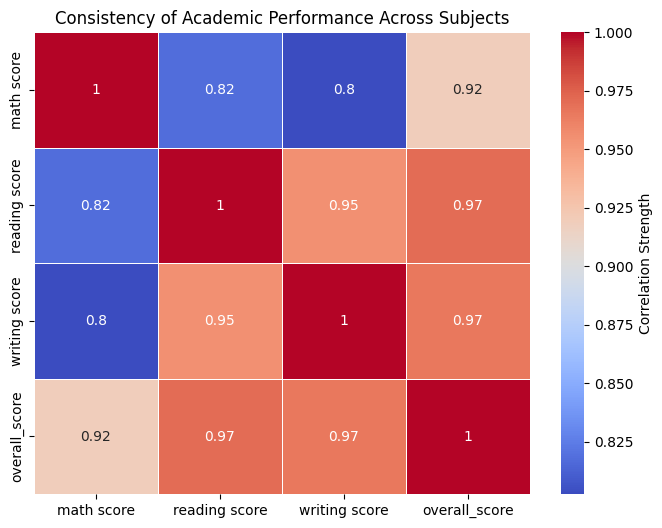

,math score,reading score,writing score,overall_score
math score,1.000000,0.817580,0.802642,0.918746
reading score,0.817580,1.000000,0.954598,0.970331
writing score,0.802642,0.954598,1.000000,0.965667
overall_score,0.918746,0.970331,0.965667,1.000000


In [40]:
# ------------------------------------------------------------
# Quantitative Analysis 1: Consistency Across Subjects [Heatmap]
# ------------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant numerical features
corr = df[['math score', 'reading score', 'writing score', 'overall_score']].corr()

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Strength'}
)

# Title
plt.title("Consistency of Academic Performance Across Subjects", fontsize=12)

plt.show()

# ------------------------------------------------------------
# Correlation Values (Detailed View)
# ------------------------------------------------------------

corr

### Interpretation: Heatmap

The heatmap shows strong positive relationships between all subject scores (math, reading, and writing).

Reading and writing scores are the most closely related, while math has slightly weaker correlations with the other subjects. However, all subjects are still strongly connected.

This means that student performance is generally consistent across subjects. Students who do well in one subject tend to do well in others, while weaker students tend to struggle overall.

From a learning analytics perspective, this suggests that performance is influenced more by general learning behavior (such as preparation and study habits) rather than just subject-specific ability.

Therefore, educators can identify struggling students early and focus on improving overall learning strategies instead of focusing on individual subjects alone.

C:\Users\anthgeb\AppData\Local\Temp\ipykernel_39696\2108022056.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


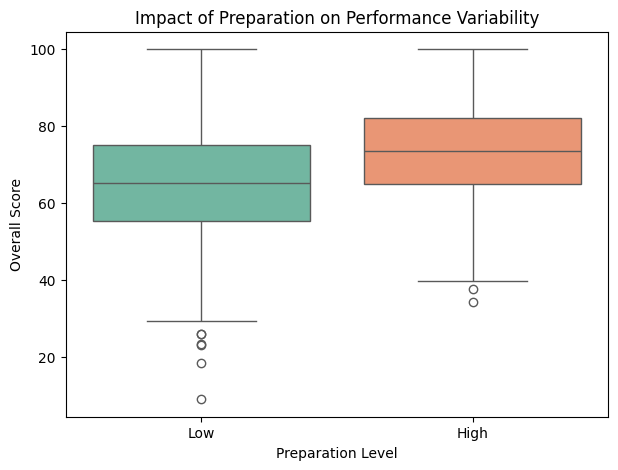

                  count       mean        std        min        25%  \
engagement_level                                                      
High              358.0  72.669460  13.036960  34.333333  65.000000   
Low               642.0  65.038941  14.186707   9.000000  55.416667   

                        50%        75%    max  
engagement_level                               
High              73.500000  82.166667  100.0  
Low               65.333333  75.000000  100.0  

Standard Deviation:
 engagement_level
High    13.036960
Low     14.186707
Name: overall_score, dtype: float64


In [41]:
# ------------------------------------------------------------
# Quantitative Analysis 2: Impact of Preparation on Performance [Boxplot]
# ------------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# Create box plot
plt.figure(figsize=(7,5))

sns.boxplot(
    x='engagement_level',
    y='overall_score',
    data=df,
    palette='Set2'
)

# Title and labels
plt.title("Impact of Preparation on Performance Variability", fontsize=12)
plt.xlabel("Preparation Level")
plt.ylabel("Overall Score")

plt.show()

# ------------------------------------------------------------
# Performance Distribution Summary
# ------------------------------------------------------------

# Summary statistics
summary_stats = df.groupby('engagement_level')['overall_score'].describe()
print(summary_stats)

# Standard deviation (measures variability)
std_dev = df.groupby('engagement_level')['overall_score'].std()
print("\nStandard Deviation:\n", std_dev)

### Interpretation: Box plot

The box plot shows a clear difference between students with low and high preparation levels.

Students who completed preparation generally achieve higher scores, with a higher median compared to those who did not prepare. This indicates that preparation has a positive impact on academic performance.

In addition, the distribution of scores for prepared students is slightly tighter, suggesting more consistent performance. In contrast, students with low preparation show a wider spread of scores, with several lower outliers, indicating more variability and inconsistency.

Overall, this suggests that preparation not only improves performance but also leads to more stable outcomes. From a learning analytics perspective, students without preparation can be considered a higher-risk group and may benefit from additional academic support or early intervention.

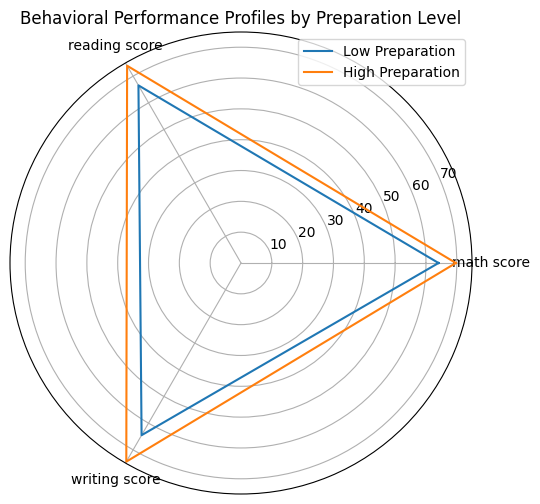

In [42]:
# ------------------------------------------------------------
# Qualitative Analysis 1: Performance Profiles [Radar Chart]
# ------------------------------------------------------------

from math import pi
import matplotlib.pyplot as plt

# Compute average scores per engagement group
radar_df = df.groupby('engagement_level')[['math score','reading score','writing score']].mean()

# Categories for radar chart
categories = ['math score','reading score','writing score']

# Extract values
low = radar_df.loc['Low'].values
high = radar_df.loc['High'].values

# Prepare angles
angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

# Close the loop
low = list(low) + [low[0]]
high = list(high) + [high[0]]

# Plot
plt.figure(figsize=(6,6))

plt.polar(angles, low, label='Low Preparation')
plt.polar(angles, high, label='High Preparation')

plt.xticks(angles[:-1], categories)

plt.title("Behavioral Performance Profiles by Preparation Level")

plt.legend(loc='upper right')
plt.show()

### Interpretation: Radar Chart

The radar chart compares the average subject scores of students with low and high preparation levels across math, reading, and writing.

Students with high preparation consistently score higher in all subjects, forming a more balanced and evenly distributed performance profile. In contrast, students with low preparation have lower scores across all areas.

The shape of the chart shows that high-preparation students perform uniformly well, while low-preparation students lag behind in every subject rather than in just one specific area.

This suggests that preparation positively impacts overall learning rather than individual subject performance. From a learning analytics perspective, this indicates that preparation supports stronger and more consistent learning behaviors.

Therefore, students with low preparation can be identified as at-risk, as their weaker and less balanced performance reflects broader learning challenges rather than isolated subject difficulties.


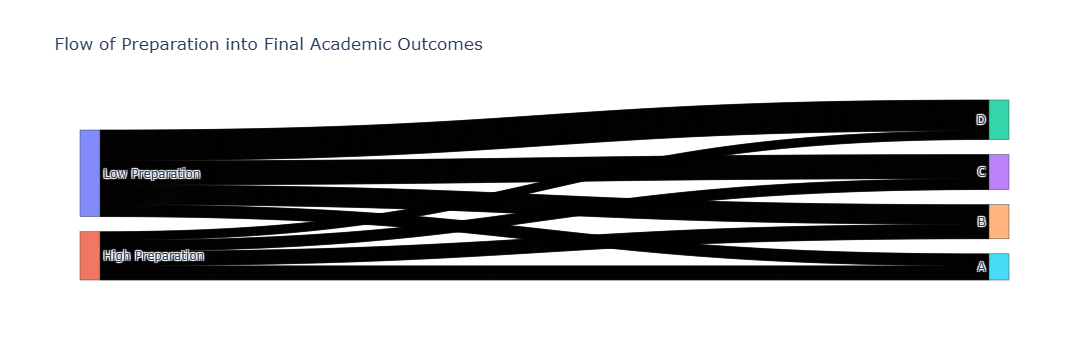

In [43]:
# ------------------------------------------------------------
# Qualitative Analysis 2: Flow of Preparation into Outcomes [Sankey Diagram]
# ------------------------------------------------------------

import plotly.graph_objects as go

# ✅ Create grade categories based on overall score
df['grade'] = pd.cut(
    df['overall_score'],
    bins=[0,60,70,80,100],
    labels=['D','C','B','A']
)

# ✅ Map categorical values to numeric positions
df['prep_num'] = df['engagement_level'].map({'Low':0,'High':1})
df['grade_num'] = df['grade'].map({'D':2,'C':3,'B':4,'A':5})

# ✅ Build Sankey Diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=["Low Preparation","High Preparation","D","C","B","A"],
        pad=15,
        thickness=20
    ),
    link=dict(
        source=df['prep_num'],
        target=df['grade_num'],
        value=[1]*len(df)
    )
)])

# Title
fig.update_layout(title_text="Flow of Preparation into Final Academic Outcomes")

fig.show()


### Interpretation: Sankey Diagram
The Sankey diagram shows how students move from preparation levels into final grade categories.

A clear pattern can be observed:
- Students with high preparation are more likely to achieve higher grades (B and A)
- Students with low preparation are more concentrated in lower grades (D and C)

This creates a visible flow where lack of preparation leads to weaker academic outcomes.

From a learning analytics perspective, this highlights preparation as an important indicator of student success. Students who do not complete preparation activities are more likely to perform poorly and can be identified early as at-risk.

Therefore, monitoring preparation behavior allows educators to take early action and provide targeted support to improve student performance.